<a href="https://colab.research.google.com/github/SUHANI-21/MachineLearningLab-2/blob/main/BasicSupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BASIC SUPERVISED LEARNING PIPELINE
# Iris Dataset + Train/Test Split + Classification
# ============================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
# ============================================================
# 2. LOAD BUILT-IN IRIS DATASET
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ============================================================
# 3. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df['target'] = y

print("\nFirst 5 rows:")
display(df.head())

# ============================================================
# 4. CHECK DATA
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)

# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])









Dataset loaded successfully!
Features shape: (150, 4)
Target shape: (150,)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Dataset shape:
(150, 5)

Training samples: 120
Testing samples: 30


In [3]:
# ============================================================
# 6. CREATE CLASSIFIER
# ============================================================

model = DecisionTreeClassifier(
    random_state=42
)

# ============================================================
# 7. TRAIN THE MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nModel training completed!")



Model training completed!


In [4]:
# ============================================================
# 8. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

print("\nPredicted values:")
print(y_pred)

print("\nActual values:")
print(y_test)



Predicted values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]

Actual values:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [5]:
# ============================================================
# 9. EVALUATE MODEL
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("\n========== MODEL EVALUATION ==========")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


========== MODEL EVALUATION ==========
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1 Score : 0.9333333333333333


In [6]:
# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)



Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [7]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


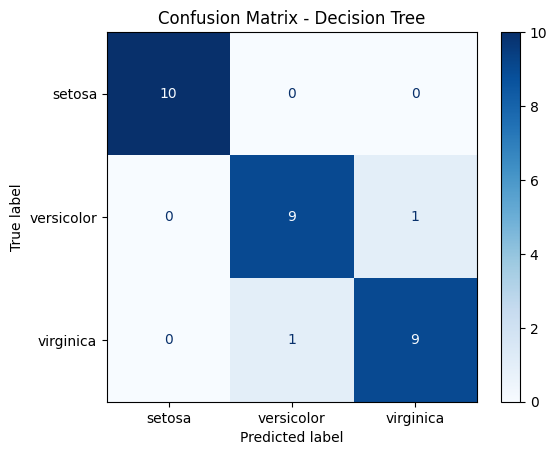

In [8]:
# ============================================================
# 12. VISUALIZE CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Decision Tree")
plt.show()
